In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("Datasets/customer_churn_dataset-testing-master.csv")

In [3]:
df= data.copy()

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [7]:
df.duplicated().any()

np.False_

In [8]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

Gender
Female    34353
Male      30021
Name: count, dtype: int64


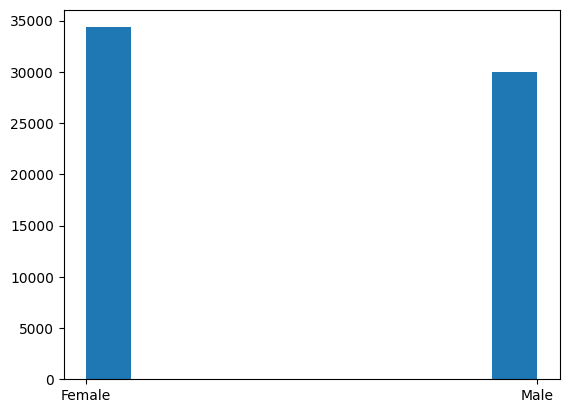

In [9]:
v=df['Gender'].value_counts()
print(v)
plt.hist(df['Gender'])
plt.show()

Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64


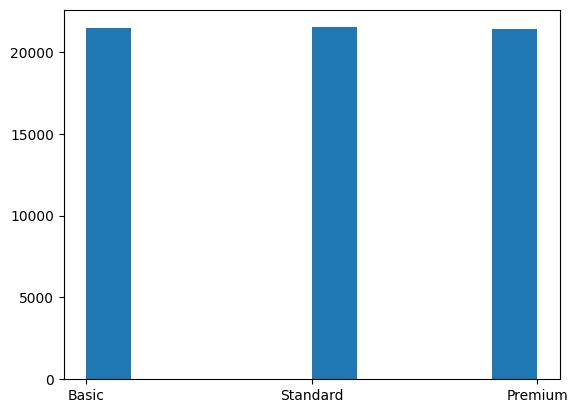

In [10]:
v=df['Subscription Type'].value_counts()
print(v)
plt.hist(df['Subscription Type'])
plt.show()

Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64


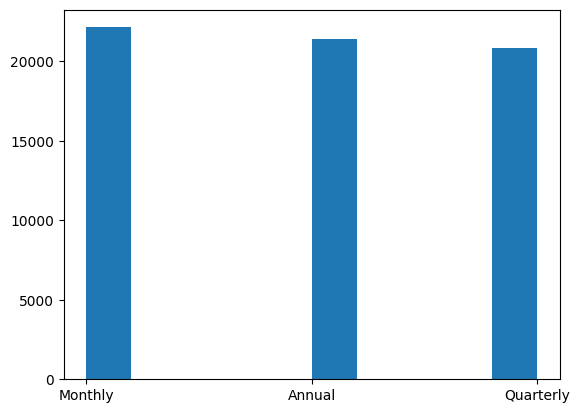

In [11]:
v=df['Contract Length'].value_counts()
print(v)
plt.hist(df['Contract Length'])
plt.show()

In [12]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [13]:
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [14]:
df=df.rename(columns={'customerid': 'customer_id'})

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

churn
0    33881
1    30493
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

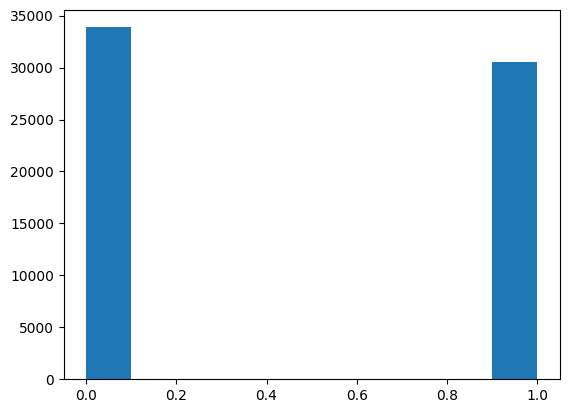

In [17]:
print(df['churn'].value_counts())
plt.hist(df['churn'])
plt.show

In [19]:
X = df.drop('churn', axis=1)
y = df['churn']

In [20]:
X = X.drop('customer_id', axis=1)

In [21]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay',
       'total_spend', 'last_interaction'],
      dtype='object')
Categorical: Index(['gender', 'subscription_type', 'contract_length'], dtype='object')


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (51499, 10)
X_test: (12875, 10)
y_train: (51499,)
y_test: (12875,)


In [24]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
churn
0    0.526321
1    0.473679
Name: proportion, dtype: float64

Testing:
churn
0    0.526291
1    0.473709
Name: proportion, dtype: float64


In [25]:
numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay',
       'total_spend', 'last_interaction'],
      dtype='object')
Categorical: Index(['gender', 'subscription_type', 'contract_length'], dtype='object')


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test_processed)

In [30]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



[[5626 1150]
 [1077 5022]]


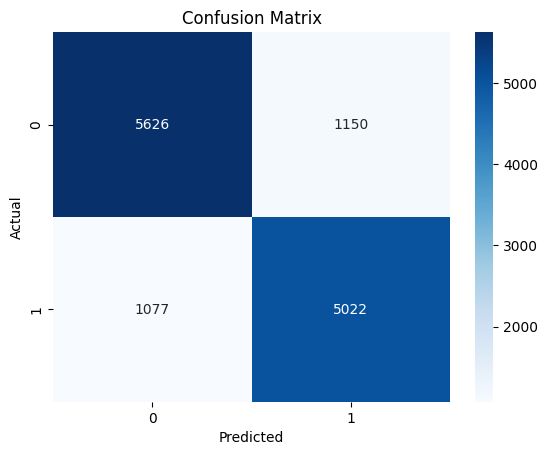

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9030001434419446
